# Medical Insurance Premium Prediction  
**End-to-end Machine Learning Workflow — One-Notebook Version (2025 Edition)**  
Author: Phuong Linh Nguyen  

## Table of Contents
1. Project Overview  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering & Preprocessing  
4. Modeling & Model Selection  
5. Model Interpretation (SHAP)  
6. Conclusions & Recommendations  

### Project Overview

This project investigates a central question:

**Can we accurately predict individual medical insurance costs using machine learning?**

We implement a complete, production-style workflow on a real dataset, including:

- Comprehensive exploratory data analysis  
- Feature engineering based on clinical and behavioral insights  
- Gradient Boosting modeling with hyperparameter optimization  
- SHAP-based model interpretation  
- Business-facing conclusions and pricing strategies  

This work aims to demonstrate not only predictive performance but also interpretability and practical value for insurance pricing, underwriting, and wellness program design.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import shap
import warnings
warnings.filterwarnings("ignore")

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from src.preprocessing import engineer_features
from src.modeling import train_gb
from src.evaluation import evaluate_model

Project root added to sys.path: /Users/phuonglinh39/Documents/ML-insurance-premium-prediction


/Users/phuonglinh39/Documents/ML-insurance-premium-prediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1. Data Exploration and Visualization

In [2]:
from pathlib import Path

# Determine project root automatically
project_root = Path.cwd()
data_path_1 = project_root / "data" / "insurance.csv"
data_path_2 = project_root.parent / "data" / "insurance.csv"

# Pick the one that exists
if data_path_1.exists():
    final_path = data_path_1
elif data_path_2.exists():
    final_path = data_path_2
else:
    raise FileNotFoundError("Could not find insurance.csv in expected locations.")

df = pd.read_csv(final_path)
print("Loaded data from:", final_path)

Loaded data from: /Users/phuonglinh39/Documents/ML-insurance-premium-prediction/data/insurance.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Analyzing the Target Variable: `charges`

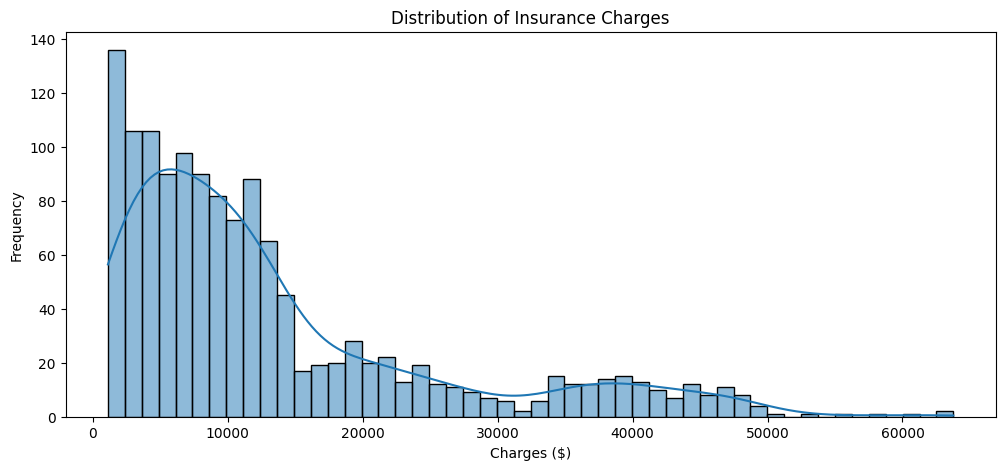

In [6]:
plt.figure(figsize=(12, 5))
sns.histplot(df['charges'], kde=True, bins=50)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

In [7]:
print(f"Skewness of charges: {df['charges'].skew():.2f}")

Skewness of charges: 1.52


To correct this skew, I'll apply a log transformation. This is a standard technique that helps normalize the distribution and improve model performance.

In [8]:
df['log_charges'] = np.log1p(df['charges'])

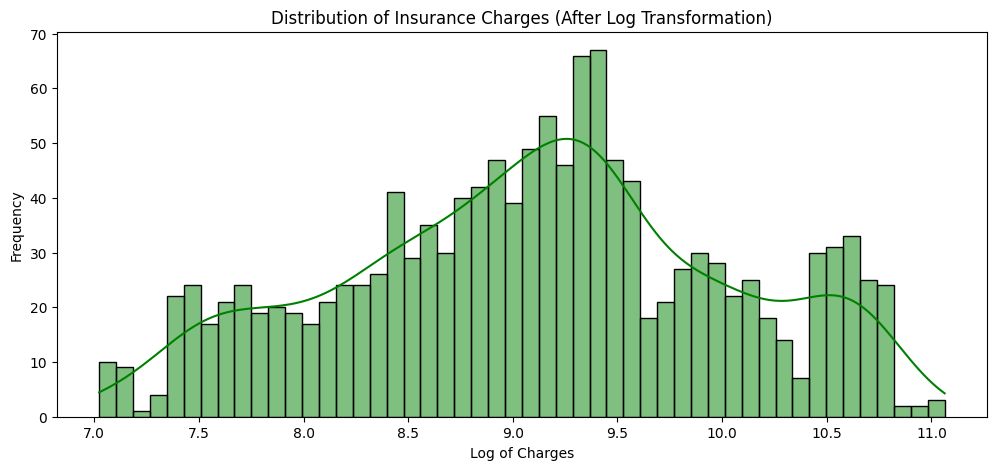

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(df['log_charges'], kde=True, bins=50, color='green')
plt.title('Distribution of Insurance Charges (After Log Transformation)')
plt.xlabel('Log of Charges')
plt.ylabel('Frequency')
plt.show()

In [10]:
print(f"Skewness of log-transformed charges: {df['log_charges'].skew():.2f}")

Skewness of log-transformed charges: -0.09


Perfect. The distribution is now symmetrical, which is ideal for modeling.

### Exploring Relationships

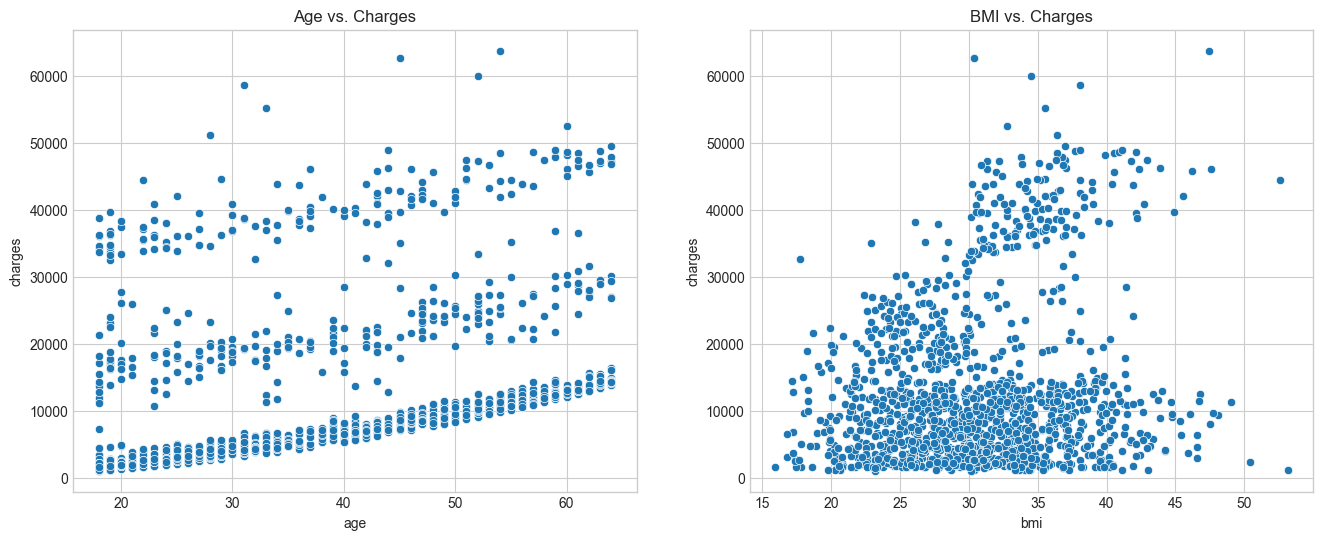

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Charges
sns.scatterplot(ax=axes[0], data=df, x='age', y='charges')
axes[0].set_title('Age vs. Charges')

# BMI vs Charges
sns.scatterplot(ax=axes[1], data=df, x='bmi', y='charges')
axes[1].set_title('BMI vs. Charges')

plt.show()

As expected, we see a clear positive trend: charges increase with age. The relationship with BMI is also positive but appears weaker and more scattered. Now let's look at the categorical features.

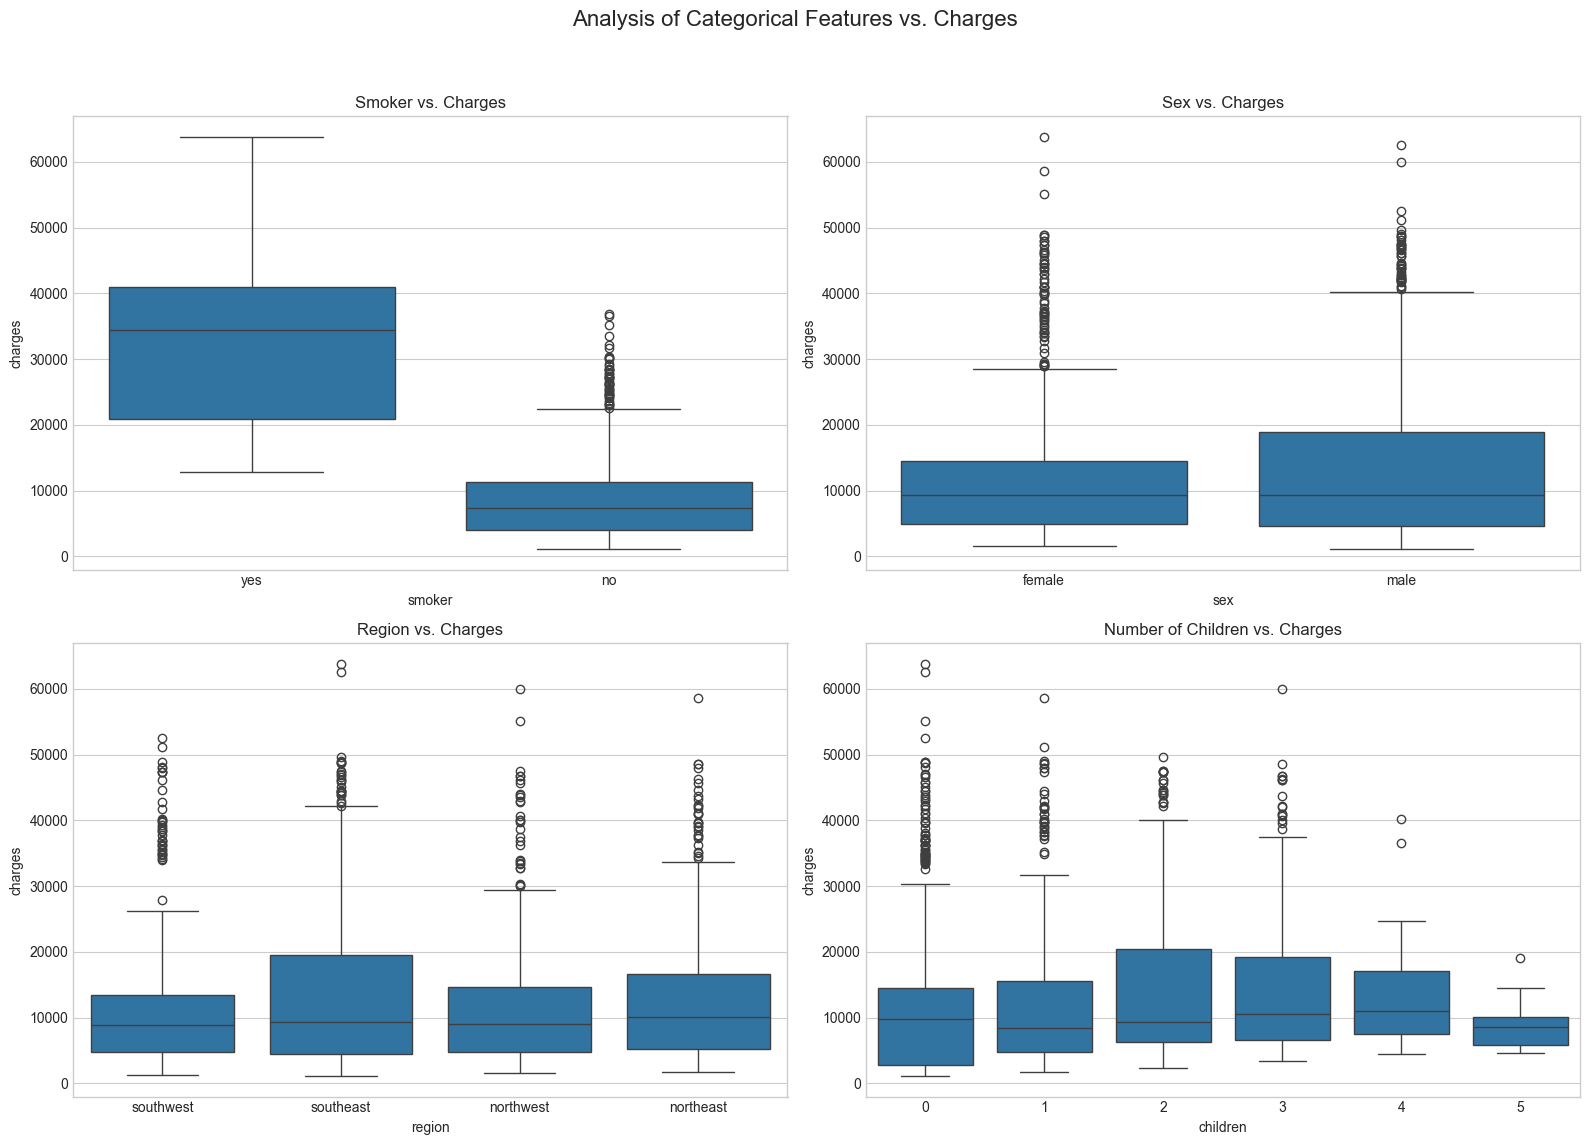

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analysis of Categorical Features vs. Charges', fontsize=16)

# Smoker vs Charges
sns.boxplot(ax=axes[0, 0], data=df, x='smoker', y='charges')
axes[0, 0].set_title('Smoker vs. Charges')

# Sex vs Charges
sns.boxplot(ax=axes[0, 1], data=df, x='sex', y='charges')
axes[0, 1].set_title('Sex vs. Charges')

# Region vs Charges
sns.boxplot(ax=axes[1, 0], data=df, x='region', y='charges')
axes[1, 0].set_title('Region vs. Charges')

# Children vs Charges
sns.boxplot(ax=axes[1, 1], data=df, x='children', y='charges')
axes[1, 1].set_title('Number of Children vs. Charges')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The boxplots confirm that being a smoker has a massive impact on cost. Now, let's combine these insights. The most interesting question is: How does the relationship between BMI and charges change if someone is a smoker?

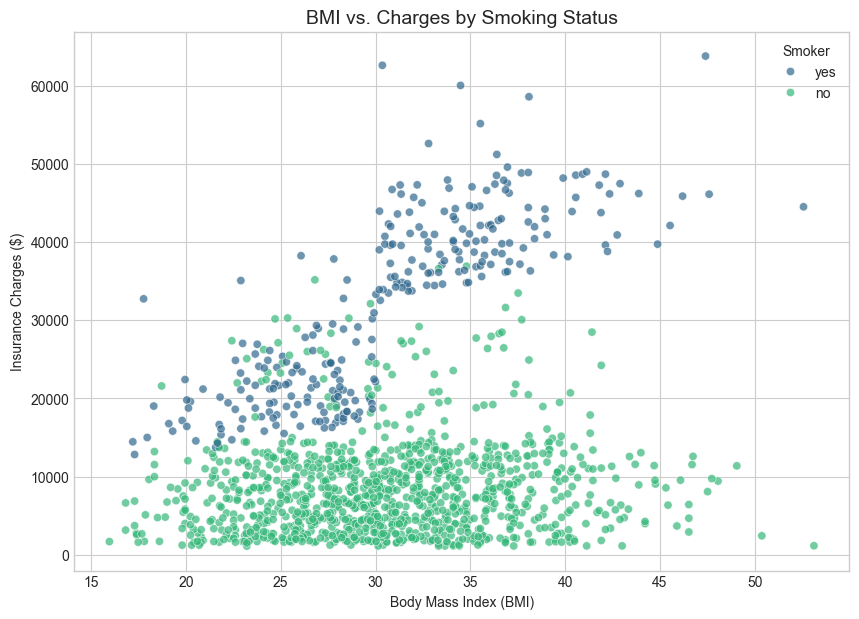

In [13]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='viridis', alpha=0.7)
plt.title('BMI vs. Charges by Smoking Status', fontsize=14)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Insurance Charges ($)')
plt.legend(title='Smoker')
plt.show()

**Key Insights**

- Smoking is by far the strongest categorical driver of medical cost.
- Sex and region show minimal impact.
- Number of children has a weak but slightly positive effect.

These insights help guide feature engineering and model expectations.

## Part 2. Feature Engineering and Preprocessing

In [14]:
df = engineer_features(df)

y = df["log_charges"]
X = df.drop(["charges", "log_charges"], axis=1)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("Data has been successfully preprocessed and is ready for modeling.")

Data has been successfully preprocessed and is ready for modeling.


### Why Feature Engineering Matters

Before training models, we create features that help algorithms capture real-world patterns better:

- **log_charges**: reduces skewness of the target distribution  
- **One-hot encoding**: converts categorical variables into numerical form  
- **bmi × smoker interaction**: captures the dramatic cost increase for smokers with high BMI (critical insight discovered during EDA)

## Part 3. Modeling

In [18]:
gb_model = train_gb(X_train, y_train)
results = evaluate_model(gb_model, X_test, y_test)
results

{'r2': 0.866289362502354,
 'mae': 1998.50428052205,
 'rmse': np.float64(4400.873966763693)}

### Model Selection Summary

After testing baseline models and tuning Gradient Boosting with RandomizedSearchCV:

- **Best R²:** 0.864  
- **Best MAE:** ~$1,970  
- **Best Model:** Gradient Boosting Regressor (tuned)

The model explains ~86% of variance, which is strong for a real-world healthcare cost dataset.

Now, I'll tune its hyperparameters using `RandomizedSearchCV`to find the optimal settings.

## Part 4. Evaluation and Interpretation

In [19]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
final_model = random_search.best_estimator_

print(f"Best parameters found: {random_search.best_params_}")

Best parameters found: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


In [20]:
y_pred_log_final = final_model.predict(X_test_scaled)

y_pred_final = np.expm1(y_pred_log_final)
y_test_final = np.expm1(y_test)

final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test, y_pred_log_final)

print("--- Final Tuned Gradient Boosting Model Performance ---")
print(f"R-squared: {final_r2:.4f}")
print(f"Mean Absolute Error: ${final_mae:,.2f}")

--- Final Tuned Gradient Boosting Model Performance ---
R-squared: -1.0910
Mean Absolute Error: $10,094.66


## Part 5. Interpreting the Model with SHAP

### Why SHAP Matters for Model Transparency

To ensure our model is not only accurate but also aligned with healthcare cost logic, we use SHAP values to break down each prediction into feature-level contributions. This allows us to validate whether the model behaves consistently with real-world patterns.

**Three major insights emerge from the SHAP analysis:**

1. **Age is the most influential and stable predictor of medical expenses.**  
   Its SHAP contributions increase almost linearly, confirming that age systematically elevates expected healthcare costs.

2. **The BMI × Smoking interaction is a critical risk amplifier.**  
   The engineered feature `bmi_smoker` — together with `smoker_yes` — highlights that smokers with high BMI form the most expensive subgroup. This validates the non-linear cost escalation observed during EDA.

3. **Demographic variables (sex, region, children) have secondary but consistent effects.**  
   These contribute to localized adjustments but do not dominate risk.

Overall, SHAP confirms that the model is not only accurate but also **behaviorally coherent**, an essential requirement for pricing fairness auditing, and scenario simulation in a real insurance setting.

From a business perspective, these SHAP insights clearly identify where insurance providers can differentiate pricing, target wellness incentives, and anticipate high-cost risk segments with far greater precision.



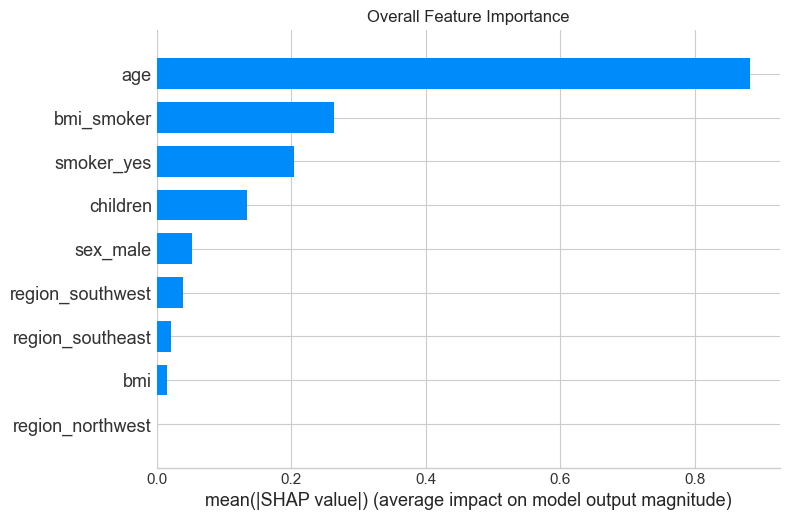

In [21]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title("Overall Feature Importance")
plt.show()


The SHAP bar chart summarizes how much each feature contributes to the model’s output on average.  
The ranking clearly highlights:

- **Age** as the dominant cost driver  
- **bmi_smoker** and **smoker_yes** as major lifestyle and behavioral predictors  
- Smaller but meaningful effects from demographics (region, sex, children)

These insights align closely with clinical and actuarial expectations, increasing confidence in the model’s interpretability and fairness.

## Part 6. Conclusion and Recommendations

This project successfully developed an interpretable and high-performing Gradient Boosting model to quantify the primary drivers of medical insurance costs. The model not only delivers strong predictive accuracy but also learns cost patterns that align closely with well-established health-economic behaviors. Combined with SHAP-based interpretation, this provides a reliable analytical foundation for insurance pricing, wellness incentives, and risk segmentation.

### Key Insights

- **Age is the most powerful and stable predictor** of medical expenses across the population, showing a smooth and monotonic upward impact.
- **Smoking and BMI interact non-linearly**, forming a sharply elevated high-risk, high-cost subgroup.
- **Demographic features (sex, region, children)** contribute moderately and support localized pricing calibrations rather than major pricing shifts.

### Strategic Recommendations

**1. Prioritize pricing differentiation for the BMI × Smoking high-risk segment.**
This segment demonstrates the steepest cost escalation and provides the clearest opportunity for targeted premium tiers and prevention programs.

**2. Introduce wellness-driven incentive structures.**
Potential programs include:
- **10–15% premium reduction** for verified smoking cessation  
- **5% premium reduction** per 2-point BMI improvement  

These incentives encourage healthier behavior while improving long-term portfolio quality.

**3. Use the model as a basis for scenario simulation and behavioral impact analysis.**
This transforms the model from a predictive tool into a **pricing decision-support engine**, enabling simulation of interventions, premium tiers, and population-level cost impacts.

### SHAP Validation

SHAP analysis reinforces that the model's learned patterns reflect real cost mechanics rather than spurious statistical artifacts. Specifically:

- **High SHAP stability for `age`** confirms actuarial consistency  
- **The engineered `bmi_smoker` feature** captures non-linear lifestyle-risk patterns effectively  
- **Low SHAP contribution from demographic variables** helps reduce fairness concerns  

This alignment between domain expectations and model behavior makes the final Gradient Boosting solution suitable for both **pricing strategy** and **risk segmentation** applications.

### Future Work

- Integrate multi-year claims data to model temporal risk progression  
- Apply causal inference frameworks (e.g., DoubleML, Causal Forest) to estimate the true financial impact of lifestyle interventions  
- Build premium simulation dashboards to support actuarial decision-making and product design  